In [1]:
#taking up a simple customer churn problem

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
data = {
    "Age": [22, 25, 28, 35, 42, 45, 50, 52, 23, 30,
            38, 41, 48, 55, 27, 33, 46, 58, 29, 37],

    "MonthlyCharges": [30, 35, 40, 55, 70, 75, 90, 95, 32, 45,
                       60, 68, 85, 100, 42, 50, 78, 110, 38, 62],

    "Tenure": [24, 30, 36, 18, 12, 8, 5, 3, 28, 40,
               20, 15, 7, 2, 34, 25, 10, 1, 32, 16],

    "Churn": [0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
              0, 1, 1, 1, 0, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

df.head()

,Age,MonthlyCharges,Tenure,Churn
0,22,30,24,0
1,25,35,30,0
2,28,40,36,0
3,35,55,18,0
4,42,70,12,1


In [4]:
X = df[["Age", "MonthlyCharges", "Tenure"]] #features/input
y = df["Churn"] #target

In [5]:
#splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
#scaling the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential()

model.add(Dense(16, input_shape=(3,), activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 0.8074 - val_accuracy: 0.0000e+00 - val_loss: 0.7829
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.1667 - loss: 0.7999 - val_accuracy: 0.0000e+00 - val_loss: 0.7744
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.2500 - loss: 0.7923 - val_accuracy: 0.5000 - val_loss: 0.7665
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.4167 - loss: 0.7849 - val_accuracy: 0.5000 - val_loss: 0.7605
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4167 - loss: 0.7776 - val_accuracy: 0.5000 - val_loss: 0.7545
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5000 - loss: 0.7705 - val_accuracy: 0.5000 - val_loss: 0.7487
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5833 - loss: 0.7638 - val_accuracy: 0.5000 - val_loss: 0.7429
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5833 - loss: 0.7574 - val_accuracy: 0.5000 - val_

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7500 - loss: 0.5905
Test Loss: 0.5904988646507263
Test Accuracy: 0.75


In [12]:
predictions = model.predict(X_test)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.5097582 ]
 [0.72951436]
 [0.4843185 ]
 [0.48905665]]


In [13]:
#converting probabilities into 0/1
y_pred = (predictions >= 0.5).astype(int)

print(y_pred)

[[1]
 [1]
 [0]
 [0]]


In [14]:
print("Actual:")
print(y_test.values)

print("Predicted:")
print(y_pred.flatten())

Actual:
[0 1 0 0]
Predicted:
[1 1 0 0]


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 1]
 [0 1]]


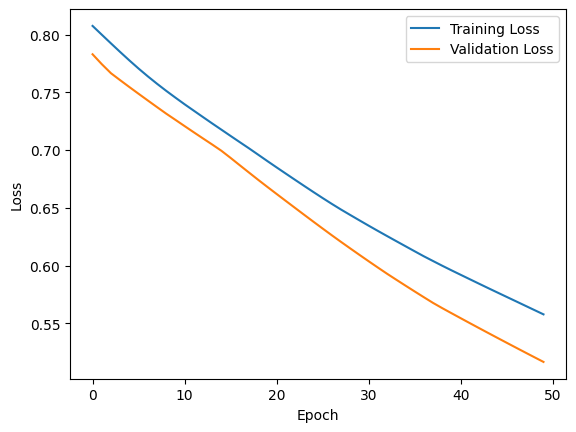

In [18]:
import matplotlib.pyplot as plt
#plot loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

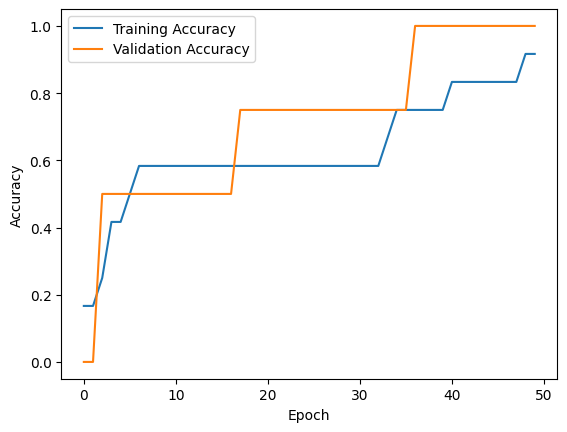

In [19]:
#plot accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()